In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [3]:
# Load data
nassau_df = pd.read_csv(
    "/content/drive/MyDrive/UNIFIED MENTOR INTERNSHIP TASKS/Nassau Candy Distributor.csv",
    encoding="ascii",
)

In [8]:
nassau_df

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
0,1,US-2021-103800-CHO-MIL-31000,03-01-2024,30-06-2026,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28
1,2,US-2021-112326-CHO-TRI-54000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60
2,3,US-2021-112326-CHO-NUT-13000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00
3,4,US-2021-112326-CHO-SCR-58000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30
4,5,US-2021-141817-CHO-TRI-54000,05-01-2024,05-07-2026,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10189,10190,US-2024-143259-CHO-MIL-31000,30-12-2025,26-06-2030,Standard Class,143259,United States,New York City,New York,10009,Chocolate,Atlantic,CHO-MIL-31000,Wonka Bar - Milk Chocolate,9.75,3,6.33,3.42
10190,10191,US-2024-115427-CHO-NUT-13000,30-12-2025,26-06-2030,Standard Class,115427,United States,Fairfield,California,94533,Chocolate,Pacific,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,6.98,2,4.98,2.00
10191,10192,US-2024-156720-CHO-SCR-58000,30-12-2025,26-06-2030,Standard Class,156720,United States,Loveland,Colorado,80538,Chocolate,Pacific,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30
10192,10193,US-2024-143259-CHO-TRI-54000,30-12-2025,26-06-2030,Standard Class,143259,United States,New York City,New York,10009,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,26.25,7,17.15,9.10


In [9]:
# Product-to-factory mapping from paste.txt
product_factory_map = {
    "Wonka Bar - Nutty Crunch Surprise": "Lot's O' Nuts",
    "Wonka Bar - Fudge Mallows": "Lot's O' Nuts",
    "Wonka Bar -Scrumdiddlyumptious": "Lot's O' Nuts",
    "Wonka Bar - Milk Chocolate": "Wicked Choccy's",
    "Wonka Bar - Triple Dazzle Caramel": "Wicked Choccy's",
    "Laffy Taffy": "Sugar Shack",
    "SweeTARTS": "Sugar Shack",
    "Nerds": "Sugar Shack",
    "Fun Dip": "Sugar Shack",
    "Fizzy Lifting Drinks": "Sugar Shack",
    "Everlasting Gobstopper": "Secret Factory",
    "Lickable Wallpaper": "Secret Factory",
    "Wonka Gum": "Secret Factory",
    "Hair Toffee": "The Other Factory",
    "Kazookles": "The Other Factory",
}

In [10]:
print(product_factory_map)

{'Wonka Bar - Nutty Crunch Surprise': "Lot's O' Nuts", 'Wonka Bar - Fudge Mallows': "Lot's O' Nuts", 'Wonka Bar -Scrumdiddlyumptious': "Lot's O' Nuts", 'Wonka Bar - Milk Chocolate': "Wicked Choccy's", 'Wonka Bar - Triple Dazzle Caramel': "Wicked Choccy's", 'Laffy Taffy': 'Sugar Shack', 'SweeTARTS': 'Sugar Shack', 'Nerds': 'Sugar Shack', 'Fun Dip': 'Sugar Shack', 'Fizzy Lifting Drinks': 'Sugar Shack', 'Everlasting Gobstopper': 'Secret Factory', 'Lickable Wallpaper': 'Secret Factory', 'Wonka Gum': 'Secret Factory', 'Hair Toffee': 'The Other Factory', 'Kazookles': 'The Other Factory'}


In [11]:
# Data preparation
work_df = nassau_df.copy()
work_df["Order Date"] = pd.to_datetime(
    work_df["Order Date"],
    format="%d-%m-%Y",
    errors="coerce",
)
work_df["Ship Date"] = pd.to_datetime(
    work_df["Ship Date"],
    format="%d-%m-%Y",
    errors="coerce",
)
work_df["Lead Time Days"] = (
    work_df["Ship Date"] - work_df["Order Date"]
).dt.days
work_df["Lead Time Days"] = pd.to_numeric(
    work_df["Lead Time Days"],
    errors="coerce",
)
work_df["Profit Margin"] = (
    work_df["Gross Profit"] / work_df["Sales"].replace(0, np.nan)
)
work_df["Current Factory"] = work_df["Product Name"].map(
    product_factory_map
)

In [12]:
# Exploratory summary
summary_tbl = (
    work_df.groupby(["Region", "Ship Mode"], as_index=False)
    .agg(
        Orders=("Order ID", "nunique"),
        Avg_Lead_Time=("Lead Time Days", "mean"),
        Median_Lead_Time=("Lead Time Days", "median"),
        Sales=("Sales", "sum"),
        Gross_Profit=("Gross Profit", "sum"),
        Margin=("Profit Margin", "mean"),
    )
    .sort_values("Avg_Lead_Time", ascending=False)
)

Dataset shape
(10194, 21)

EDA summary
      Region       Ship Mode  Orders  Avg_Lead_Time  Median_Lead_Time  \
9   Interior        Same Day      98    1397.233333            1269.0   
8   Interior     First Class     273    1352.435644            1272.0   
13   Pacific        Same Day     153    1344.437838            1269.0   
12   Pacific     First Class     431    1340.935922            1272.0   
0   Atlantic     First Class     407    1335.568548            1272.0   
2   Atlantic    Second Class     456    1329.855839            1273.0   
14   Pacific    Second Class     543    1327.543171            1273.0   
6       Gulf    Second Class     276    1324.717325            1273.0   
4       Gulf     First Class     201    1319.824786            1272.0   
3   Atlantic  Standard Class    1487    1319.303982            1274.0   

       Sales  Gross_Profit    Margin  
9    1433.34        949.82  0.669312  
8    4160.97       2755.48  0.664701  
13   2391.54       1586.78  0.664893  
1

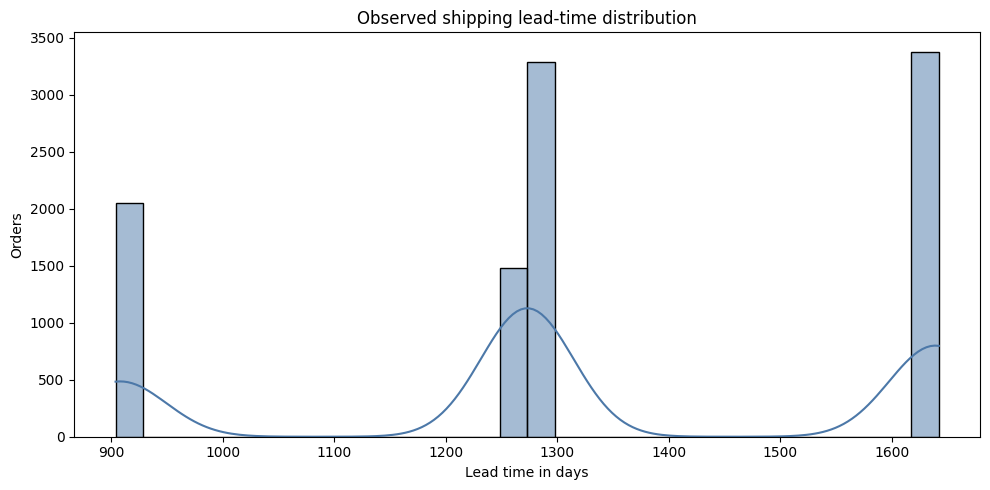

In [13]:
print("Dataset shape")
print(work_df.shape)
print("\nEDA summary")
print(summary_tbl.head(10))

plt.figure(figsize=(10, 5))
sns.histplot(
    work_df["Lead Time Days"],
    bins=30,
    kde=True,
    color="#4C78A8",
)
plt.title("Observed shipping lead-time distribution")
plt.xlabel("Lead time in days")
plt.ylabel("Orders")
plt.tight_layout()
plt.show()



In [14]:
# Remove extreme outliers using the IQR rule
q1_value = work_df["Lead Time Days"].quantile(0.25)
q3_value = work_df["Lead Time Days"].quantile(0.75)
iqr_value = q3_value - q1_value
lower_bound = q1_value - 1.5 * iqr_value
upper_bound = q3_value + 1.5 * iqr_value

model_df = work_df[
    work_df["Lead Time Days"].between(lower_bound, upper_bound)
].copy()

In [15]:
# Predictive modeling
feature_cols = [
    "Product Name",
    "Current Factory",
    "Region",
    "Ship Mode",
    "Division",
    "Units",
    "Sales",
    "Gross Profit",
]
target_col = "Lead Time Days"

model_input = model_df[feature_cols + [target_col]].dropna().copy()
X_data = model_input[feature_cols]
y_data = model_input[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X_data,
    y_data,
    test_size=0.2,
    random_state=42,
)

categorical_cols = [
    "Product Name",
    "Current Factory",
    "Region",
    "Ship Mode",
    "Division",
]
numeric_cols = ["Units", "Sales", "Gross Profit"]

preprocess = ColumnTransformer(
    transformers=[
        (
            "cat",
            Pipeline(
                steps=[
                    (
                        "imputer",
                        SimpleImputer(strategy="most_frequent"),
                    ),
                    (
                        "onehot",
                        OneHotEncoder(handle_unknown="ignore"),
                    ),
                ]
            ),
            categorical_cols,
        ),
        (
            "num",
            Pipeline(
                steps=[
                    (
                        "imputer",
                        SimpleImputer(strategy="median"),
                    ),
                    ("scale", StandardScaler()),
                ]
            ),
            numeric_cols,
        ),
    ]
)

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(
        n_estimators=180,
        random_state=42,
        n_jobs=-1,
        min_samples_leaf=3,
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42,
        n_estimators=160,
        max_depth=3,
        learning_rate=0.05,
    ),
}

metrics_rows = []

for model_name in tqdm(models, desc="Training models"):
    model_pipe = Pipeline(
        steps=[
            ("prep", preprocess),
            ("model", models[model_name]),
        ]
    )
    model_pipe.fit(X_train, y_train)
    predictions = model_pipe.predict(X_test)

    metrics_rows.append(
        {
            "Model": model_name,
            "RMSE": mean_squared_error(
                y_test,
                predictions,
            )
            ** 0.5,
            "MAE": mean_absolute_error(
                y_test,
                predictions,
            ),
            "R2": r2_score(y_test, predictions),
        }
    )

metrics_df = pd.DataFrame(metrics_rows).sort_values(
    ["RMSE", "MAE"]
)

print("\nModel metrics")
print(metrics_df)



Training models:   0%|          | 0/3 [00:00<?, ?it/s]


Model metrics
               Model        RMSE         MAE        R2
0  Linear Regression  266.795399  215.301587 -0.006492
2  Gradient Boosting  267.712652  216.002523 -0.013424
1      Random Forest  273.030118  221.633308 -0.054083


In [16]:
# Factory and region coordinates from paste.txt
factory_coords = {
    "Lot's O' Nuts": (32.881893, -111.768036),
    "Wicked Choccy's": (32.076176, -81.088371),
    "Sugar Shack": (48.11914, -96.18115),
    "Secret Factory": (41.446333, -90.565487),
    "The Other Factory": (35.1175, -89.971107),
}

region_coords = {
    "Atlantic": (40.0, -74.0),
    "Interior": (41.9, -87.6),
    "Pacific": (34.1, -118.2),
    "Gulf": (29.8, -95.4),
}


def haversine_km(
    lat_1,
    lon_1,
    lat_2,
    lon_2,
):
    earth_radius_km = 6371.0
    lat_1, lon_1, lat_2, lon_2 = map(
        np.radians,
        [lat_1, lon_1, lat_2, lon_2],
    )
    delta_lat = lat_2 - lat_1
    delta_lon = lon_2 - lon_1
    haversine_a = (
        np.sin(delta_lat / 2) ** 2
        + np.cos(lat_1)
        * np.cos(lat_2)
        * np.sin(delta_lon / 2) ** 2
    )
    return 2 * earth_radius_km * np.arcsin(
        np.sqrt(haversine_a)
    )


In [17]:
# Calculate factory-to-region distances
route_rows = []

for region_name, region_point in region_coords.items():
    region_lat, region_lon = region_point

    for factory_name, factory_point in factory_coords.items():
        factory_lat, factory_lon = factory_point
        route_rows.append(
            {
                "Region": region_name,
                "Factory": factory_name,
                "Distance_km": haversine_km(
                    factory_lat,
                    factory_lon,
                    region_lat,
                    region_lon,
                ),
            }
        )

route_dist_df = pd.DataFrame(route_rows)

In [18]:
# Historical lead-time fallback tables
prod_route = (
    model_df.groupby(
        ["Product Name", "Region", "Ship Mode"],
        as_index=False,
    )["Lead Time Days"]
    .mean()
    .rename(columns={"Lead Time Days": "Baseline_Lead"})
)

prod_region = (
    model_df.groupby(
        ["Product Name", "Region"],
        as_index=False,
    )["Lead Time Days"]
    .mean()
    .rename(columns={"Lead Time Days": "Product_Region_Lead"})
)

region_mode = (
    model_df.groupby(
        ["Region", "Ship Mode"],
        as_index=False,
    )["Lead Time Days"]
    .mean()
    .rename(columns={"Lead Time Days": "Region_Mode_Lead"})
)

region_avg = (
    model_df.groupby("Region", as_index=False)["Lead Time Days"]
    .mean()
    .rename(columns={"Lead Time Days": "Region_Lead"})
)


In [19]:
# Scenario simulation
products = model_df[
    ["Product Name", "Division", "Current Factory"]
].drop_duplicates()

scenario_rows = []

for _, product_row in tqdm(
    products.iterrows(),
    total=len(products),
    desc="Simulating factory scenarios",
):
    product_name = product_row["Product Name"]
    current_factory = product_row["Current Factory"]
    division = product_row["Division"]

    for region_name in region_coords:
        for ship_mode in model_df["Ship Mode"].unique():
            exact_match = prod_route[
                (prod_route["Product Name"] == product_name)
                & (prod_route["Region"] == region_name)
                & (prod_route["Ship Mode"] == ship_mode)
            ]

            if len(exact_match) > 0:
                baseline_lead = float(
                    exact_match["Baseline_Lead"].iloc[0]
                )
            else:
                product_region_match = prod_region[
                    (prod_region["Product Name"] == product_name)
                    & (prod_region["Region"] == region_name)
                ]
                region_mode_match = region_mode[
                    (region_mode["Region"] == region_name)
                    & (region_mode["Ship Mode"] == ship_mode)
                ]
                region_match = region_avg[
                    region_avg["Region"] == region_name
                ]

                if len(product_region_match) > 0:
                    baseline_lead = float(
                        product_region_match[
                            "Product_Region_Lead"
                        ].iloc[0]
                    )
                elif len(region_mode_match) > 0:
                    baseline_lead = float(
                        region_mode_match[
                            "Region_Mode_Lead"
                        ].iloc[0]
                    )
                else:
                    baseline_lead = float(
                        region_match["Region_Lead"].iloc[0]
                    )

            current_distance = route_dist_df[
                (route_dist_df["Region"] == region_name)
                & (route_dist_df["Factory"] == current_factory)
            ]["Distance_km"].iloc[0]

            for candidate_factory in factory_coords:
                candidate_distance = route_dist_df[
                    (route_dist_df["Region"] == region_name)
                    & (
                        route_dist_df["Factory"]
                        == candidate_factory
                    )
                ]["Distance_km"].iloc[0]

                predicted_lead = baseline_lead * (
                    candidate_distance / current_distance
                ) ** 0.35

                scenario_rows.append(
                    {
                        "Product Name": product_name,
                        "Division": division,
                        "Region": region_name,
                        "Ship Mode": ship_mode,
                        "Current Factory": current_factory,
                        "Candidate Factory": candidate_factory,
                        "Distance_km": candidate_distance,
                        "Predicted Lead Time Days": predicted_lead,
                        "Baseline Lead Time Days": baseline_lead,
                    }
                )

scenario_df = pd.DataFrame(scenario_rows)
scenario_df["Lead Time Reduction Days"] = (
    scenario_df["Baseline Lead Time Days"]
    - scenario_df["Predicted Lead Time Days"]
)
scenario_df["Lead Time Reduction %"] = (
    100
    * scenario_df["Lead Time Reduction Days"]
    / scenario_df["Baseline Lead Time Days"]
)
scenario_df["Reassignment"] = np.where(
    scenario_df["Candidate Factory"]
    != scenario_df["Current Factory"],
    "Reassign",
    "Keep",
)

Simulating factory scenarios:   0%|          | 0/15 [00:00<?, ?it/s]

In [20]:
# Profit sensitivity and confidence calculations
profit_by_product = (
    model_df.groupby("Product Name", as_index=False)
    .agg(
        Avg_Gross_Profit=("Gross Profit", "mean"),
        Orders=("Order ID", "count"),
    )
)

scenario_df = scenario_df.merge(
    profit_by_product,
    on="Product Name",
    how="left",
)

scenario_df["Estimated Profit Impact"] = (
    scenario_df["Avg_Gross_Profit"]
    * (scenario_df["Lead Time Reduction %"] / 100)
    * 0.15
)

scenario_df["Confidence Score"] = np.clip(
    0.55
    + 0.35 * np.minimum(scenario_df["Orders"] / 1000, 1),
    0,
    0.90,
)

scenario_df["Recommendation Score"] = (
    scenario_df["Lead Time Reduction %"]
    + 0.002 * scenario_df["Estimated Profit Impact"]
)

ranking_cols = ["Product Name", "Region", "Ship Mode"]
scenario_df["Rank"] = scenario_df.groupby(
    ranking_cols
)["Recommendation Score"].rank(
    method="first",
    ascending=False,
)

top_recommendations = scenario_df[
    (scenario_df["Rank"] == 1)
    & (
        scenario_df["Candidate Factory"]
        != scenario_df["Current Factory"]
    )
].copy()

top_recommendations = top_recommendations.sort_values(
    ["Lead Time Reduction %", "Estimated Profit Impact"],
    ascending=False,
)

print("\nTop recommendations")
print(
    top_recommendations[
        [
            "Product Name",
            "Region",
            "Ship Mode",
            "Current Factory",
            "Candidate Factory",
            "Baseline Lead Time Days",
            "Predicted Lead Time Days",
            "Lead Time Reduction %",
            "Estimated Profit Impact",
            "Confidence Score",
        ]
    ].head(15)
)


Top recommendations
                          Product Name    Region       Ship Mode  \
273     Wonka Bar -Scrumdiddlyumptious  Interior    Second Class   
263     Wonka Bar -Scrumdiddlyumptious  Interior  Standard Class   
268     Wonka Bar -Scrumdiddlyumptious  Interior     First Class   
278     Wonka Bar -Scrumdiddlyumptious  Interior        Same Day   
188  Wonka Bar - Nutty Crunch Surprise  Interior     First Class   
193  Wonka Bar - Nutty Crunch Surprise  Interior    Second Class   
343          Wonka Bar - Fudge Mallows  Interior  Standard Class   
353          Wonka Bar - Fudge Mallows  Interior    Second Class   
183  Wonka Bar - Nutty Crunch Surprise  Interior  Standard Class   
198  Wonka Bar - Nutty Crunch Surprise  Interior        Same Day   
348          Wonka Bar - Fudge Mallows  Interior     First Class   
358          Wonka Bar - Fudge Mallows  Interior        Same Day   
45          Wonka Bar - Milk Chocolate   Pacific     First Class   
120  Wonka Bar - Triple Daz

In [21]:
# KPI summary
kpi_tbl = pd.DataFrame(
    {
        "KPI": [
            "Lead Time Reduction %",
            "Profit Impact Stability",
            "Scenario Confidence Score",
            "Recommendation Coverage",
        ],
        "Value": [
            top_recommendations[
                "Lead Time Reduction %"
            ].mean(),
            float(
                np.clip(
                    1
                    - top_recommendations[
                        "Estimated Profit Impact"
                    ].std()
                    / max(
                        abs(
                            top_recommendations[
                                "Estimated Profit Impact"
                            ].mean()
                        ),
                        1,
                    ),
                    0,
                    1,
                )
            ),
            top_recommendations["Confidence Score"].mean(),
            top_recommendations["Product Name"].nunique()
            / products["Product Name"].nunique(),
        ],
    }
)

print("\nKPI summary")
print(kpi_tbl)


KPI summary
                         KPI      Value
0      Lead Time Reduction %  30.397859
1    Profit Impact Stability   0.532842
2  Scenario Confidence Score   0.662581
3    Recommendation Coverage   1.000000


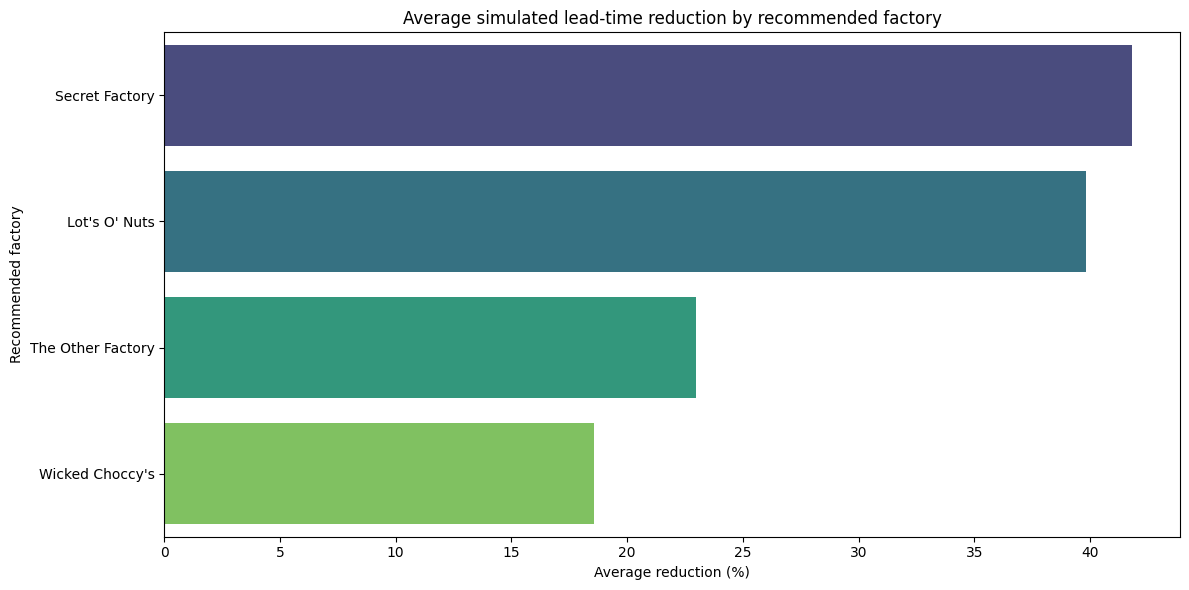

In [22]:
# Recommendation visualization
plot_df = (
    top_recommendations.groupby(
        "Candidate Factory",
        as_index=False,
    )["Lead Time Reduction %"]
    .mean()
    .sort_values("Lead Time Reduction %", ascending=False)
)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=plot_df,
    x="Lead Time Reduction %",
    y="Candidate Factory",
    hue="Candidate Factory",
    palette="viridis",
    legend=False,
)
plt.title(
    "Average simulated lead-time reduction by recommended factory"
)
plt.xlabel("Average reduction (%)")
plt.ylabel("Recommended factory")
plt.tight_layout()
plt.show()


In [23]:
# Export results
output_xlsx = "nassau_factory_optimization_results.xlsx"
output_csv = "top_factory_recommendations.csv"

with pd.ExcelWriter(output_xlsx, engine="openpyxl") as writer:
    summary_tbl.to_excel(
        writer,
        sheet_name="EDA Summary",
        index=False,
    )
    metrics_df.to_excel(
        writer,
        sheet_name="Model Metrics",
        index=False,
    )
    top_recommendations.to_excel(
        writer,
        sheet_name="Top Recommendations",
        index=False,
    )
    kpi_tbl.to_excel(
        writer,
        sheet_name="KPI Summary",
        index=False,
    )
    route_dist_df.to_excel(
        writer,
        sheet_name="Route Distances",
        index=False,
    )

top_recommendations.to_csv(
    output_csv,
    index=False,
)

print("\nCreated files")
print(output_xlsx)
print(output_csv)



Created files
nassau_factory_optimization_results.xlsx
top_factory_recommendations.csv


In [32]:
from google.colab import files

files.download("nassau_factory_optimization_results.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>